# Canonicalization of Guitar Fretboards from Video Frames
This notebook is a demo of extrscting a canonical, top-down view of a guitar fretboard from raw video frames. This is an improvement on a previous demo that used only a Mask R-CNN seg mask. The original method worked fairly well, but struggled when the mask was noisy or partially occluded by hands.

**Next steps:** switch to YOLO?

In [60]:
import os
import numpy as np
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torchvision.transforms as T
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from itertools import product
from IPython.display import Audio, display

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"using {device}")

# FFT Configuration
SR = 44100
TUNING = [82.41, 110.00, 146.83, 196.00, 246.94, 329.63]
STRING_NAMES = ['E2', 'A2', 'D3', 'G3', 'B3', 'E4']

using cpu


In [61]:
def get_model_instance_segmentation(num_classes: int = 2):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes,
    )
    return model


def load_fretboard_model(weights_path: str, num_classes: int = 2, device: torch.device = device):
    model = get_model_instance_segmentation(num_classes)
    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

## FFT Chord Detection Functions

In [62]:
def freq_from_fret(open_freq: float, fret: int) -> float:
    return open_freq * (2 ** (fret / 12))

def karplus_strong(freq: float, dur: float = 2.0, sr: int = SR) -> np.ndarray:
    N = int(sr * dur)
    if freq <= 0:
        return np.zeros(N, dtype=np.float32)

    L = max(2, int(sr / freq))
    buf = np.random.uniform(-1, 1, L).astype(np.float32)
    out = np.zeros(N, dtype=np.float32)

    for i in range(N):
        out[i] = buf[i % L]
        buf[i % L] = 0.996 * 0.5 * (buf[i % L] + buf[(i + 1) % L])

    return out

def synth_chord_array(frets, dur: float = 2.0, sr: int = SR) -> np.ndarray:
    layers = []
    for i, f in enumerate(frets):
        if f == "X":
            continue
        freq = freq_from_fret(TUNING[i], int(f))
        layers.append(karplus_strong(freq, dur=dur, sr=sr))

    if not layers:
        return np.zeros(int(sr * dur), dtype=np.float32)

    mix = np.sum(layers, axis=0).astype(np.float32)
    mix /= (np.max(np.abs(mix)) + 1e-9)
    return mix

In [63]:
def enumerate_possible_chords(
    overlaps,
    allow_open: bool = True,
    allow_mute: bool = True,
    allow_press: bool = True
):
    assert len(overlaps) == 6, "Provide exactly 6 strings (low E to high E)."

    per_string_options = []
    for val in overlaps:
        opts = []
        if val is None:
            if allow_open: opts.append(0)
            if allow_mute: opts.append("X")
        else:
            if allow_press: opts.append(int(val))
            if allow_open:  opts.append(0)
            if allow_mute:  opts.append("X")
        per_string_options.append(opts)

    seen = set()
    chords = []
    for combo in product(*per_string_options):
        if all(c == "X" for c in combo):  # skip all-muted
            continue
        tup = tuple(combo)
        if tup not in seen:
            seen.add(tup)
            chords.append(list(combo))
    return chords

In [64]:
def _frame_audio(audio: np.ndarray, sr: int = SR, win_s: float = 0.046, hop_s: float = 0.023):
    win = int(win_s * sr)
    hop = int(hop_s * sr)
    if win < 32:
        win = 2048
    if hop < 16:
        hop = win // 2

    nfft = 1
    while nfft < win:
        nfft *= 2

    w = np.hanning(win).astype(np.float32)
    frames = []
    for start in range(0, max(1, len(audio) - win), hop):
        seg = audio[start:start + win]
        if len(seg) < win:
            seg = np.pad(seg, (0, win - len(seg)))
        X = np.fft.rfft(seg * w, n=nfft)
        frames.append(np.abs(X))

    if not frames:
        X = np.fft.rfft(np.pad(audio, (0, win - len(audio))), n=nfft)
        frames = [np.abs(X)]

    S = np.stack(frames, axis=0)
    freqs = np.fft.rfftfreq(nfft, d=1 / sr)
    spec = np.median(S, axis=0)
    spec = spec / (np.max(spec) + 1e-9)
    return spec, freqs

def _hz_to_idx(freqs: np.ndarray, hz: float) -> int:
    if hz <= freqs[0]:
        return 0
    if hz >= freqs[-1]:
        return len(freqs) - 1
    return int(np.argmin(np.abs(freqs - hz)))

def _candidate_harmonics_for_string(open_hz: float, fret: int, max_hz: float, max_harm: int = 6):
    f0 = freq_from_fret(open_hz, fret)
    hs = []
    for h in range(1, max_harm + 1):
        fh = f0 * h
        if fh > max_hz:
            break
        hs.append(fh)
    return hs

def _collect_expected_harmonics(frets, freqs: np.ndarray, max_harm: int = 6):
    expected = []
    for s_idx, f in enumerate(frets):
        if f == "X":
            continue
        if isinstance(f, (int, np.integer)):
            expected.extend(
                _candidate_harmonics_for_string(TUNING[s_idx], int(f), freqs[-1], max_harm=max_harm)
            )
    return expected

def _cents_window(hz: float, cents: float = 35):
    r = 2 ** (cents / 1200.0)
    return hz / r, hz * r

def score_chord_against_audio(
    frets,
    test_spec: np.ndarray,
    test_freqs: np.ndarray,
    cents_tol: float = 35,
    max_harm: int = 6
) -> float:
    expected = _collect_expected_harmonics(frets, test_freqs, max_harm=max_harm)
    if not expected:
        return 0.0

    cumsum = np.cumsum(test_spec)
    tot = cumsum[-1] + 1e-9
    score = 0.0

    for fh in expected:
        lo, hi = _cents_window(fh, cents=cents_tol)
        i0 = _hz_to_idx(test_freqs, lo)
        i1 = _hz_to_idx(test_freqs, hi)
        if i1 <= i0:
            i1 = min(i0 + 1, len(test_spec) - 1)
        band_energy = cumsum[i1] - (cumsum[i0 - 1] if i0 > 0 else 0.0)
        score += band_energy

    return float(score / tot)

def rank_chords_by_audio(
    possible_chords,
    test_audio: np.ndarray | None = None,
    test_wav: str | None = None,
    sr: int = SR,
    cents_tol: float = 35,
    max_harm: int = 6,
    top_k: int = 10
):
    assert (test_audio is not None) or (test_wav is not None), "Provide test_audio or test_wav."

    if test_wav is not None:
        import wave
        with wave.open(test_wav, 'rb') as wf:
            assert wf.getnchannels() == 1, "Use mono WAV."
            assert wf.getsampwidth() == 2, "Use 16-bit PCM WAV."
            assert wf.getframerate() == sr, f"WAV must be {sr} Hz."
            frames = wf.readframes(wf.getnframes())
            test_audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0
    else:
        test_audio = np.asarray(test_audio, dtype=np.float32)

    test_audio = test_audio - np.mean(test_audio)
    peak = np.max(np.abs(test_audio)) + 1e-9
    test_audio = test_audio / peak

    test_spec, test_freqs = _frame_audio(test_audio, sr=sr)
    scored = []
    for ch in possible_chords:
        s = score_chord_against_audio(ch, test_spec, test_freqs, cents_tol=cents_tol, max_harm=max_harm)
        scored.append((ch, s))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_k]

In [126]:
transform = T.Compose([T.ToTensor()])

def get_fretboard_mask_from_image(model, img_pil, device=device, confidence_threshold: float = 0.5):
    img_tensor = transform(img_pil).to(device)
    with torch.no_grad():
        prediction = model([img_tensor])[0]

    scores = prediction["scores"].detach().cpu().numpy()
    labels = prediction["labels"].detach().cpu().numpy()
    masks = prediction["masks"].detach().cpu().numpy()  # (N, 1, H, W)

    H, W = img_pil.size[1], img_pil.size[0]
    combined_mask = np.zeros((H, W), dtype=np.uint8)

    for i, score in enumerate(scores):
        if score < confidence_threshold:
            continue
        if labels[i] != 1:
            continue
        m = masks[i, 0]  # (H, W)
        m_bin = (m > 0.3).astype(np.uint8)
        combined_mask = np.logical_or(combined_mask, m_bin).astype(np.uint8)

    combined_mask = (combined_mask * 255).astype(np.uint8)
    return combined_mask

In [127]:
def clean_mask(mask: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    if mask.max() == 1:
        mask = (mask * 255).astype(np.uint8)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask_closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask_opened = cv2.morphologyEx(mask_closed, cv2.MORPH_OPEN, kernel)

    # Connected components to keep largest region only
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats((mask_opened > 0).astype(np.uint8), connectivity=8)
    if num_labels <= 1:
        return (mask_opened > 0).astype(np.uint8) * 255

    # Skip background (label 0), find largest area
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_label = 1 + np.argmax(areas)
    cleaned = (labels == largest_label).astype(np.uint8) * 255
    return cleaned


def get_contour_and_min_area_rect(mask: np.ndarray):
    contours, _ = cv2.findContours((mask > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None
    contour = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(contour)
    box = cv2.boxPoints(rect)  # 4x2 float
    box = np.array(box, dtype=np.float32)
    return contour, box


def order_corners_tl_tr_bl_br(box: np.ndarray) -> np.ndarray:
    assert box.shape == (4, 2)
    # Based on sums and differences
    s = box.sum(axis=1)
    diff = np.diff(box, axis=1)[:, 0]

    tl = box[np.argmin(s)]
    br = box[np.argmax(s)]
    tr = box[np.argmin(diff)]
    bl = box[np.argmax(diff)]

    return np.array([tl, tr, bl, br], dtype=np.float32)

In [128]:
def compute_homography_and_warp(image_bgr: np.ndarray,
                                src_corners: np.ndarray,
                                out_width: int = 1024,
                                out_height: int = 256) -> (np.ndarray, np.ndarray):
    assert src_corners.shape == (4, 2)

    dst_corners = np.array([
        [0, 0],
        [out_width - 1, 0],
        [0, out_height - 1],
        [out_width - 1, out_height - 1],
    ], dtype=np.float32)

    H = cv2.getPerspectiveTransform(src_corners.astype(np.float32), dst_corners)
    warped = cv2.warpPerspective(image_bgr, H, (out_width, out_height))
    return warped, H

In [129]:
# === User configuration ===
MODEL_WEIGHTS_PATH = "../model_weights.pt"
IMAGE_PATH = "../demos/fretboard_canonicalization/guitar_test_clean.png"
CONFIDENCE_THRESHOLD = 0.3
OUT_WIDTH, OUT_HEIGHT = 1024, 256

assert os.path.exists(MODEL_WEIGHTS_PATH), f"Weights not found: {MODEL_WEIGHTS_PATH}"
assert os.path.exists(IMAGE_PATH), f"Image not found: {IMAGE_PATH}"

model = load_fretboard_model(MODEL_WEIGHTS_PATH, num_classes=2, device=device)
print("Model loaded :)")

Model loaded :)


In [ ]:

def adjust_image(img, brightness=0, contrast=1.0, saturation=1.0):
    """
    Args:
        brightness: -100 ~ 100 (0 = no change)
        contrast: 0.5 ~ 3.0 (1.0 = no change)
        saturation: 0.0 ~ 2.0 (1.0 = no change)
    """
    # 밝기/대비 조정
    adjusted = cv2.convertScaleAbs(img, alpha=contrast, beta=brightness)
    
    # 채도 조정
    if len(adjusted.shape) == 3 and saturation != 1.0:
        hsv = cv2.cvtColor(adjusted, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * saturation, 0, 255)
        adjusted = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    
    return adjusted

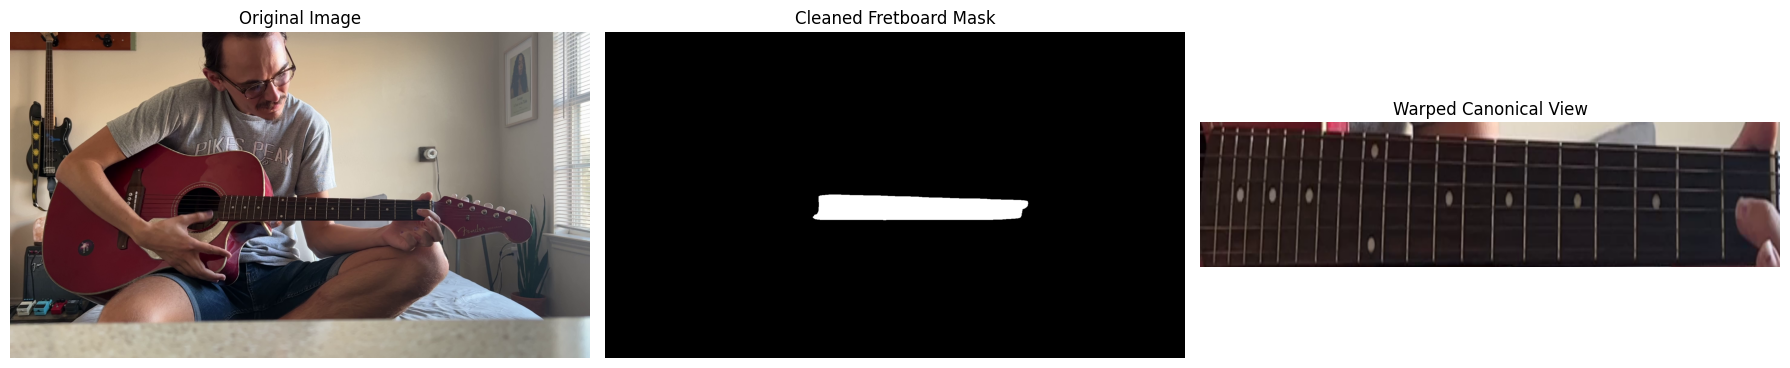

In [131]:
def run_full_pipeline(image_path: str):

    img_pil = Image.open(image_path).convert("RGB")
    img_np = np.array(img_pil)[:, :, ::-1]

    # 1) segmentation to binary mask
    raw_mask = get_fretboard_mask_from_image(model, img_pil, device=device, confidence_threshold=CONFIDENCE_THRESHOLD)

    # 2) cleaning mask
    cleaned_mask = clean_mask(raw_mask, kernel_size=5)
    
    # 3) contour + min-area rectangle
    contour, box = get_contour_and_min_area_rect(cleaned_mask)
    if contour is None or box is None:
        print("no fretboard contour found")
        return

    src_corners = order_corners_tl_tr_bl_br(box)

    # 4) computing homography and warping
    warped_bgr, H = compute_homography_and_warp(img_np, src_corners,
                                                out_width=OUT_WIDTH,
                                                out_height=OUT_HEIGHT)

    # visualization
    vis_bgr = img_np.copy()
    cv2.drawContours(vis_bgr, [contour], -1, (0, 255, 0), 2)
    cv2.polylines(vis_bgr, [src_corners.astype(np.int32)], isClosed=True, color=(0, 0, 255), thickness=2)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(cleaned_mask, cmap="gray")
    axes[1].set_title("Cleaned Fretboard Mask")
    axes[1].axis("off")

    axes[2].imshow(cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Warped Canonical View")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "homography": H,
        "src_corners": src_corners,
        "warped": warped_bgr,
        "mask": cleaned_mask,
    }


results = run_full_pipeline(IMAGE_PATH)

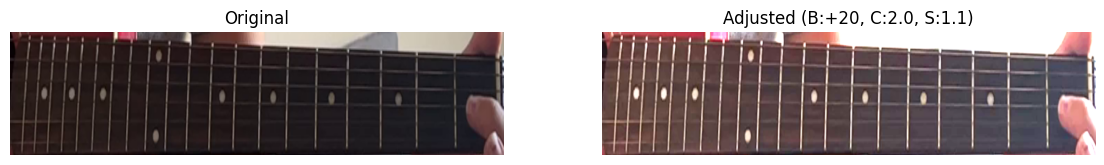

In [141]:
warped_bgr = results["warped"]
# 사용 예시
adjusted_img = adjust_image(warped_bgr, brightness=20, contrast=2.0, saturation=1.1)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(adjusted_img, cv2.COLOR_BGR2RGB))
plt.title("Adjusted (B:+20, C:2.0, S:1.1)")
plt.axis('off')
plt.show()

In [142]:
# ============================================
# Step 2b: Detect frets (vertical lines) in warped fretboard
# ============================================
def detect_frets_in_warped(warped_bgr: np.ndarray, 
                            debug: bool = True):
    """
    Detect fret X-coordinates using Canny Edge + Hough Line Transform.
    찾는 것: 세로 선(frets)
    """
    H, W = warped_bgr.shape[:2]
    
    # Convert to grayscale
    gray = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY)
    
    # Canny Edge Detection
    edges = cv2.Canny(gray, threshold1=30, threshold2=100)
    
    # Hough Line Transform
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=80,
        minLineLength=int(H * 0.1),
        maxLineGap=30
    )
    
    if lines is None:
        print("⚠️  No frets detected.")
        return []
    
    # Filter for vertical lines (near 90 degrees)
    vertical_xs = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if y2 == y1:
            continue
        angle = abs(np.degrees(np.arctan2(x2 - x1, y2 - y1)))
        # Vertical lines: angle near 0 or 180
        if angle < 5 or angle > 175:
            vertical_xs.append((x1 + x2) // 2)
    
    if not vertical_xs:
        print("⚠️  No vertical lines found.")
        return []
    
    # Merge nearby X-coordinates
    vertical_xs = sorted(vertical_xs)
    merged_xs = []
    cluster = []
    
    for x in vertical_xs:
        if not cluster:
            cluster = [x]
        elif x - cluster[-1] <= 15:
            cluster.append(x)
        else:
            merged_xs.append(int(np.mean(cluster)))
            cluster = [x]
    if cluster:
        merged_xs.append(int(np.mean(cluster)))
    
    fret_xs = sorted(merged_xs)
    
    # Debug visualization
    if debug:
        vis = warped_bgr.copy()
        colors = [(255,0,0),(0,255,0),(0,0,255),
                  (255,255,0),(0,255,255),(255,0,255)]
        for i, x in enumerate(fret_xs):
            color = colors[i % len(colors)]
            cv2.line(vis, (x, 0), (x, H), color, 2)
            cv2.putText(vis, f"Fret {i}", (x-10, 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
        
        fig = plt.figure(figsize=(14, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(edges, cmap='gray')
        plt.title("Canny Edge Detection")
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f"Detected Frets: {len(fret_xs)} vertical lines")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return fret_xs

print("✓ Fret detection function defined")


✓ Fret detection function defined


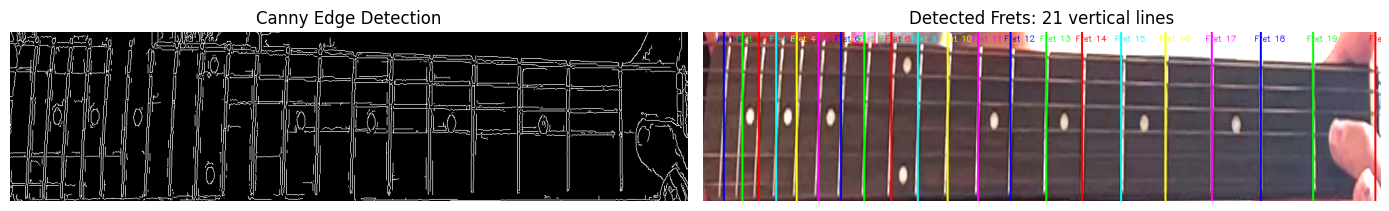


✓ Detected 21 frets at X positions: [31, 59, 84, 110, 141, 174, 208, 243, 284, 324, 369, 415, 464, 518, 572, 631, 698, 768, 842, 921, 1015]


In [ ]:
# Detect frets (vertical lines)
if results:
    fret_xs = detect_frets_in_warped(adjusted_img, debug=True)
    print(f"\n✓ Detected {len(fret_xs)} frets at X positions: {fret_xs}")
else:
    print("No results available. Run the pipeline first.")
